=== Pretraining MAE ===
[Pretrain] Epoch 1/50 Loss: 1.0595
[Pretrain] Epoch 2/50 Loss: 0.7946
[Pretrain] Epoch 3/50 Loss: 0.7055
[Pretrain] Epoch 4/50 Loss: 0.6339
[Pretrain] Epoch 5/50 Loss: 0.5786
[Pretrain] Epoch 6/50 Loss: 0.5377
[Pretrain] Epoch 7/50 Loss: 0.5072
[Pretrain] Epoch 8/50 Loss: 0.4809
[Pretrain] Epoch 9/50 Loss: 0.4565
[Pretrain] Epoch 10/50 Loss: 0.4450
[Pretrain] Epoch 11/50 Loss: 0.4302
[Pretrain] Epoch 12/50 Loss: 0.4182
[Pretrain] Epoch 13/50 Loss: 0.4077
[Pretrain] Epoch 14/50 Loss: 0.4005
[Pretrain] Epoch 15/50 Loss: 0.3900
[Pretrain] Epoch 16/50 Loss: 0.3824
[Pretrain] Epoch 17/50 Loss: 0.3762
[Pretrain] Epoch 18/50 Loss: 0.3718
[Pretrain] Epoch 19/50 Loss: 0.3654
[Pretrain] Epoch 20/50 Loss: 0.3608
[Pretrain] Epoch 21/50 Loss: 0.3564
[Pretrain] Epoch 22/50 Loss: 0.3521
[Pretrain] Epoch 23/50 Loss: 0.3508
[Pretrain] Epoch 24/50 Loss: 0.3462
[Pretrain] Epoch 25/50 Loss: 0.3418
[Pretrain] Epoch 26/50 Loss: 0.3391
[Pretrain] Epoch 27/50 Loss: 0.3393
[Pretrain] Ep

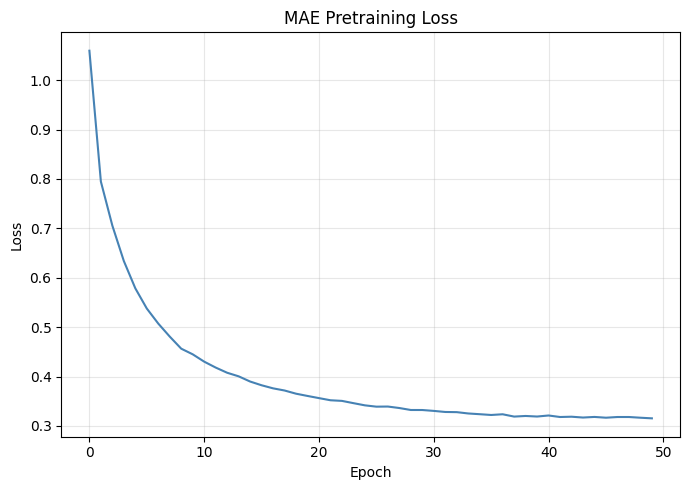

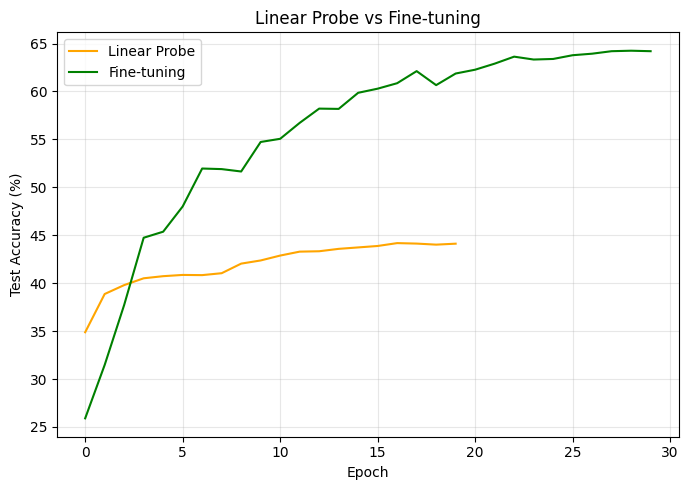

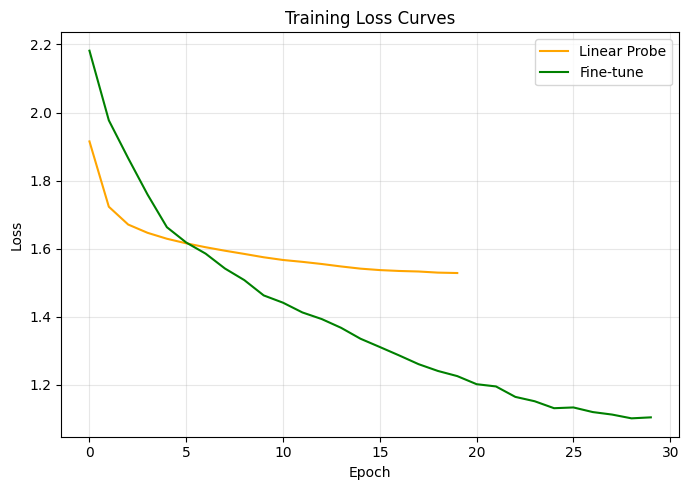

Running t-SNE for: t-SNE: Pretrained Features...


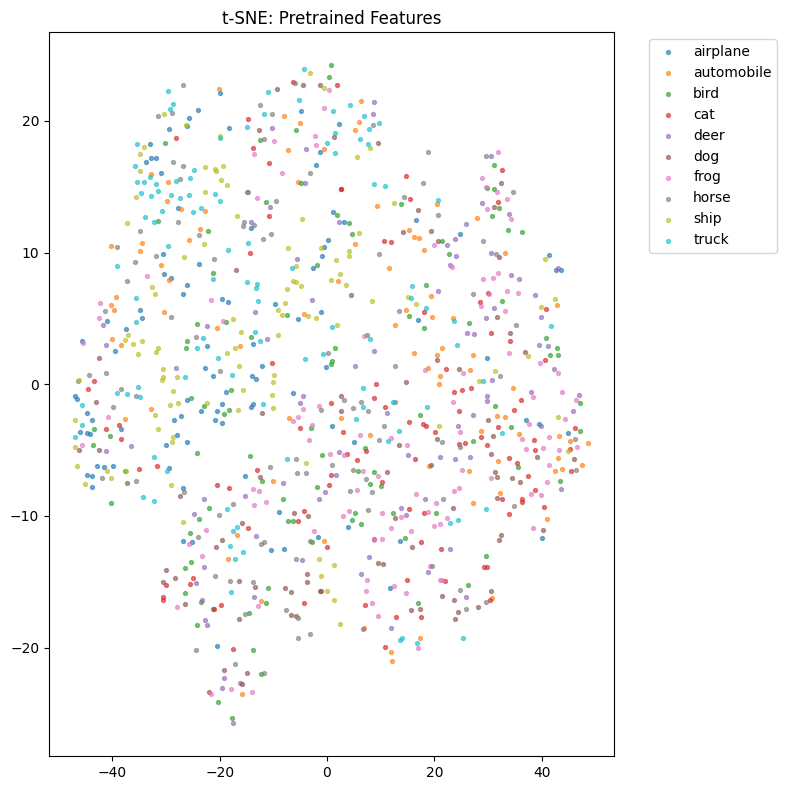

Running t-SNE for: t-SNE: Fine-tuned Features...


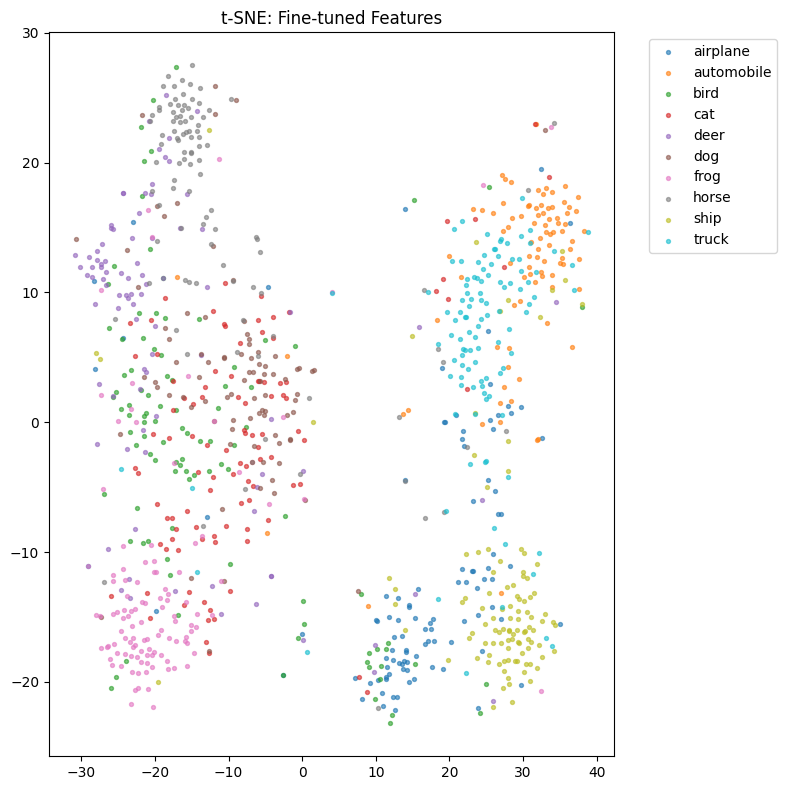

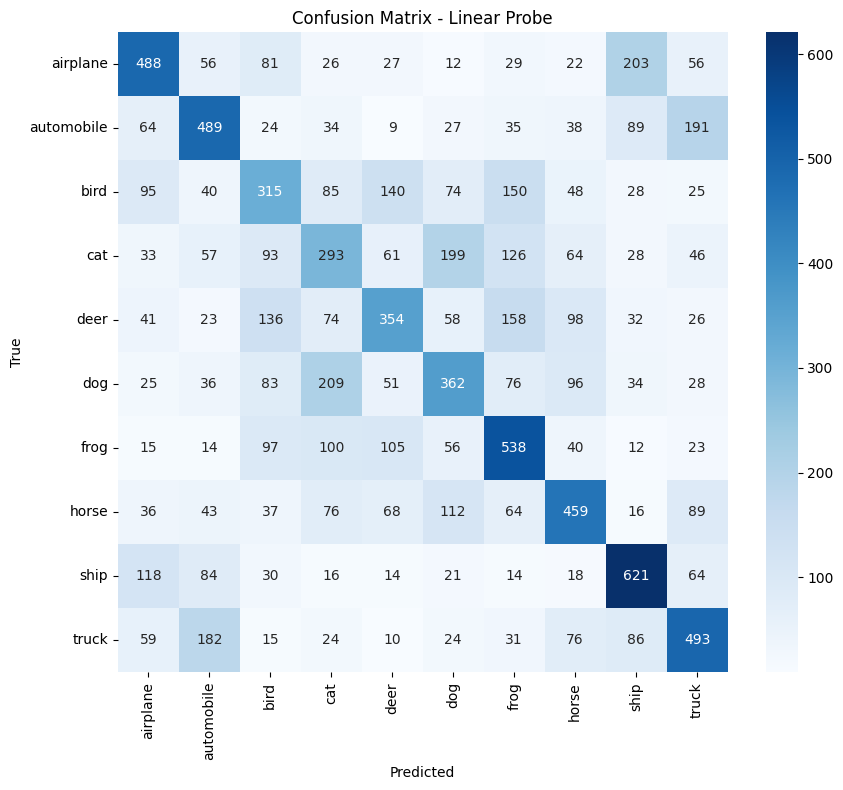

Overall Accuracy: 44.12%


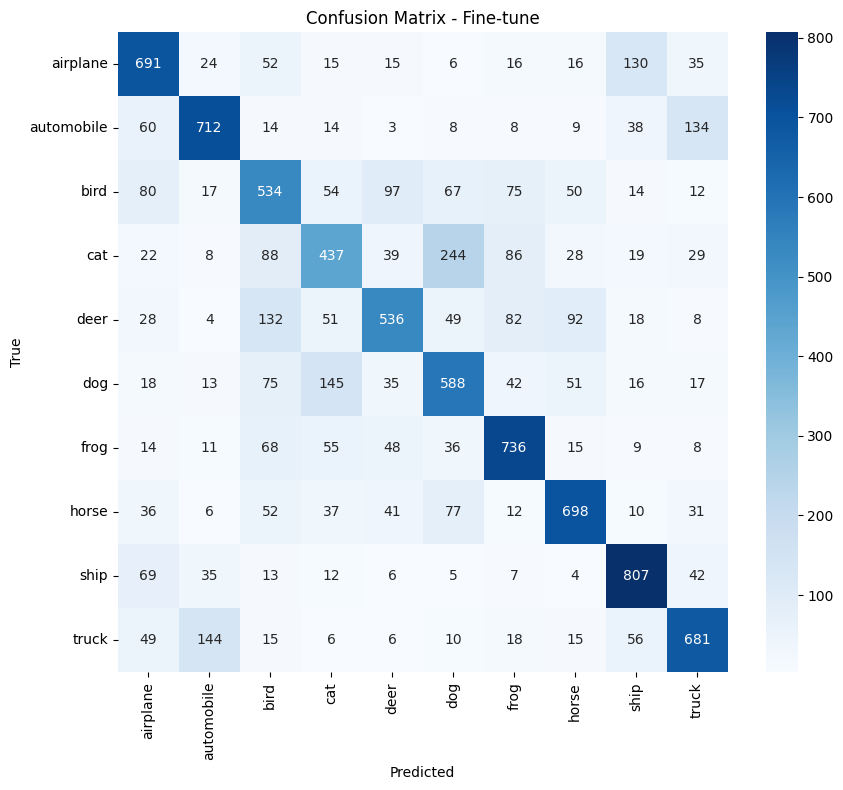

Overall Accuracy: 64.20%


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as T
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix
import pandas as pd
import copy
from einops import rearrange
from timm.models.vision_transformer import Block

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------- Patch Embedding & Pos Embed ----------------
class PatchEmbed(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_chans=3, embed_dim=128):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
    def forward(self, x):
        x = self.proj(x)
        return rearrange(x, 'b c h w -> b (h w) c')

def get_2d_sincos_pos_embed(embed_dim, grid_size):
    grid = np.arange(grid_size, dtype=np.float32)
    grid_h, grid_w = np.meshgrid(grid, grid)
    pe_h = get_1d_sincos_pos_embed(embed_dim // 2, grid_h.reshape(-1))
    pe_w = get_1d_sincos_pos_embed(embed_dim // 2, grid_w.reshape(-1))
    return np.concatenate([pe_h, pe_w], axis=1)

def get_1d_sincos_pos_embed(embed_dim, pos):
    omega = np.arange(embed_dim // 2, dtype=np.float32)
    omega /= embed_dim / 2.
    omega = 1. / 10000 ** omega
    out = np.einsum('m,d->md', pos, omega)
    return np.concatenate([np.sin(out), np.cos(out)], axis=1)

# ---------------- MAE Model (smaller, faster) ----------------
class MAE_ViT(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_chans=3,
                 embed_dim=128, depth=6, num_heads=4,
                 decoder_embed_dim=64, decoder_depth=2, decoder_num_heads=4,
                 mlp_ratio=4., mask_ratio=0.75):
        super().__init__()
        self.patch_size = patch_size
        self.mask_ratio = mask_ratio
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        num_patches = self.patch_embed.num_patches
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim), requires_grad=False)
        self.blocks = nn.ModuleList([Block(embed_dim, num_heads, mlp_ratio, qkv_bias=True, norm_layer=nn.LayerNorm) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)

        self.decoder_embed = nn.Linear(embed_dim, decoder_embed_dim, bias=True)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_embed_dim))
        self.decoder_pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, decoder_embed_dim), requires_grad=False)
        self.decoder_blocks = nn.ModuleList([Block(decoder_embed_dim, decoder_num_heads, mlp_ratio, qkv_bias=True, norm_layer=nn.LayerNorm) for _ in range(decoder_depth)])
        self.decoder_norm = nn.LayerNorm(decoder_embed_dim)
        self.decoder_pred = nn.Linear(decoder_embed_dim, patch_size**2 * in_chans, bias=True)
        self.initialize_weights()

    def initialize_weights(self):
        grid_size = int(self.patch_embed.num_patches ** 0.5)
        pos_embed = get_2d_sincos_pos_embed(self.pos_embed.shape[-1], grid_size)
        self.pos_embed.data.copy_(torch.from_numpy(np.concatenate([np.zeros((1, self.pos_embed.shape[-1])), pos_embed], axis=0)).float().unsqueeze(0))
        decoder_pos_embed = get_2d_sincos_pos_embed(self.decoder_pos_embed.shape[-1], grid_size)
        self.decoder_pos_embed.data.copy_(torch.from_numpy(np.concatenate([np.zeros((1, self.decoder_pos_embed.shape[-1])), decoder_pos_embed], axis=0)).float().unsqueeze(0))
        torch.nn.init.normal_(self.cls_token, std=.02)
        torch.nn.init.normal_(self.mask_token, std=.02)
        self.apply(self._init_w)

    def _init_w(self, m):
        if isinstance(m, nn.Linear):
            torch.nn.init.xavier_uniform_(m.weight)
            if m.bias is not None: nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)

    def patchify(self, imgs):
        p = self.patch_size
        return rearrange(imgs, 'b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1=p, p2=p)

    def random_masking(self, x, mask_ratio):
        N, L, D = x.shape
        len_keep = int(L * (1 - mask_ratio))
        noise = torch.rand(N, L, device=x.device)
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1)
        ids_keep = ids_shuffle[:, :len_keep]
        x_masked = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).repeat(1, 1, D))
        mask = torch.ones([N, L], device=x.device)
        mask[:, :len_keep] = 0
        mask = torch.gather(mask, dim=1, index=ids_restore)
        return x_masked, mask, ids_restore

    def forward_encoder(self, x, mask_ratio):
        x = self.patch_embed(x)
        x = x + self.pos_embed[:, 1:, :]
        x, mask, ids_restore = self.random_masking(x, mask_ratio)
        cls_token = self.cls_token + self.pos_embed[:, :1, :]
        cls_tokens = cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        for blk in self.blocks: x = blk(x)
        return self.norm(x), mask, ids_restore

    def forward_decoder(self, x, ids_restore):
        x = self.decoder_embed(x)
        mask_tokens = self.mask_token.repeat(x.shape[0], ids_restore.shape[1] + 1 - x.shape[1], 1)
        x_ = torch.cat([x[:, 1:, :], mask_tokens], dim=1)
        x_ = torch.gather(x_, dim=1, index=ids_restore.unsqueeze(-1).repeat(1, 1, x.shape[2]))
        x = torch.cat([x[:, :1, :], x_], dim=1)
        x = x + self.decoder_pos_embed
        for blk in self.decoder_blocks: x = blk(x)
        x = self.decoder_norm(x)
        return self.decoder_pred(x)[:, 1:, :]

    def forward_loss(self, imgs, pred, mask):
        target = self.patchify(imgs)
        loss = (pred - target) ** 2
        loss = loss.mean(dim=-1)
        return (loss * mask).sum() / mask.sum()

    def forward(self, imgs, mask_ratio=None):
        if mask_ratio is None: mask_ratio = self.mask_ratio
        latent, mask, ids_restore = self.forward_encoder(imgs, mask_ratio)
        pred = self.forward_decoder(latent, ids_restore)
        return self.forward_loss(imgs, pred, mask), pred, mask

    def forward_encoder_full(self, x):
        x = self.patch_embed(x)
        x = x + self.pos_embed[:, 1:, :]
        cls_token = self.cls_token + self.pos_embed[:, :1, :]
        cls_tokens = cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        for blk in self.blocks: x = blk(x)
        return self.norm(x)


# ---------------- Data (subset for speed) ----------------
def get_dataloaders(batch_size=512, subset_frac=0.3):
    mean, std = (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)
    train_tf_pre = T.Compose([T.RandomResizedCrop(32, scale=(0.2, 1.0)), T.RandomHorizontalFlip(), T.ToTensor(), T.Normalize(mean, std)])
    train_tf_eval = T.Compose([T.RandomCrop(32, padding=4), T.RandomHorizontalFlip(), T.ToTensor(), T.Normalize(mean, std)])
    test_tf = T.Compose([T.ToTensor(), T.Normalize(mean, std)])

    full_train = torchvision.datasets.CIFAR10('./data', train=True, download=True)
    n = len(full_train)
    subset_idx = np.random.RandomState(42).choice(n, int(n * subset_frac), replace=False)

    train_pre = torch.utils.data.Subset(torchvision.datasets.CIFAR10('./data', train=True, transform=train_tf_pre), subset_idx)
    train_eval = torch.utils.data.Subset(torchvision.datasets.CIFAR10('./data', train=True, transform=train_tf_eval), subset_idx)
    train_lin = torch.utils.data.Subset(torchvision.datasets.CIFAR10('./data', train=True, transform=test_tf), subset_idx)
    test_set = torchvision.datasets.CIFAR10('./data', train=False, transform=test_tf)

    return (
        DataLoader(train_pre, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True, drop_last=True),
        DataLoader(train_eval, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True),
        DataLoader(train_lin, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True),
        DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    )

# ---------------- Train Functions ----------------
def pretrain_mae(model, train_loader, device, epochs=50, lr=1.5e-4):
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.05, betas=(0.9, 0.95))
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    history = {'loss': []}
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for imgs, _ in train_loader:
            imgs = imgs.to(device)
            loss, _, _ = model(imgs)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item()
        scheduler.step()
        avg = total_loss / len(train_loader)
        history['loss'].append(avg)
        print(f"[Pretrain] Epoch {epoch+1}/{epochs} Loss: {avg:.4f}")
    return model, history

class LinearProbe(nn.Module):
    def __init__(self, encoder, embed_dim=128, num_classes=10):
        super().__init__()
        self.encoder = encoder
        for p in self.encoder.parameters(): p.requires_grad = False
        self.bn = nn.BatchNorm1d(embed_dim, affine=False)
        self.head = nn.Linear(embed_dim, num_classes)
    def forward(self, x):
        with torch.no_grad():
            feats = self.encoder.forward_encoder_full(x)[:, 0]
        return self.head(self.bn(feats))

class FineTuneModel(nn.Module):
    def __init__(self, encoder, embed_dim=128, num_classes=10):
        super().__init__()
        self.encoder = encoder
        self.head = nn.Linear(embed_dim, num_classes)
    def forward(self, x):
        feats = self.encoder.forward_encoder_full(x)[:, 0]
        return self.head(feats)

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = model(imgs).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return 100. * correct / total

def linear_probe(mae_model, train_loader, test_loader, device, epochs=20, lr=0.1, embed_dim=128):
    model = LinearProbe(mae_model, embed_dim=embed_dim).to(device)
    optimizer = torch.optim.SGD(model.head.parameters(), lr=lr, momentum=0.9)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'test_acc': []}
    for epoch in range(epochs):
        model.train(); model.encoder.eval()
        total_loss = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            loss = criterion(model(imgs), labels)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item()
        scheduler.step()
        acc = evaluate(model, test_loader, device)
        history['train_loss'].append(total_loss/len(train_loader))
        history['test_acc'].append(acc)
        print(f"[LinearProbe] Epoch {epoch+1}/{epochs} Test Acc: {acc:.2f}%")
    return model, history

def finetune(mae_model, train_loader, test_loader, device, epochs=30, lr=1e-3, embed_dim=128):
    model = FineTuneModel(mae_model, embed_dim=embed_dim).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.05)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    history = {'train_loss': [], 'test_acc': []}
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            loss = criterion(model(imgs), labels)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item()
        scheduler.step()
        acc = evaluate(model, test_loader, device)
        history['train_loss'].append(total_loss/len(train_loader))
        history['test_acc'].append(acc)
        print(f"[Finetune] Epoch {epoch+1}/{epochs} Test Acc: {acc:.2f}%")
    return model, history

# ---------------- Visualization Functions ----------------
def make_results_table(lp_history, ft_history):
    df = pd.DataFrame({
        'Method': ['Linear Probe', 'Fine-tuning'],
        'Final Test Accuracy (%)': [lp_history['test_acc'][-1], ft_history['test_acc'][-1]],
        'Best Test Accuracy (%)': [max(lp_history['test_acc']), max(ft_history['test_acc'])],
        'Trainable Params': ['Head only', 'Full encoder + head'],
    })
    print("\n=== Results Table ===")
    print(df.to_string(index=False))
    df.to_csv("results_table.csv", index=False)
    return df

def plot_pretrain_loss(history, save_path="pretrain_loss_curve.png"):
    plt.figure(figsize=(7,5))
    plt.plot(history['loss'], color='steelblue')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('MAE Pretraining Loss')
    plt.grid(alpha=0.3); plt.tight_layout(); plt.savefig(save_path, dpi=150); plt.show()

def plot_accuracy_curves(lp_history, ft_history, save_path="accuracy_curves.png"):
    plt.figure(figsize=(7,5))
    plt.plot(lp_history['test_acc'], label='Linear Probe', color='orange')
    plt.plot(ft_history['test_acc'], label='Fine-tuning', color='green')
    plt.xlabel('Epoch'); plt.ylabel('Test Accuracy (%)')
    plt.title('Linear Probe vs Fine-tuning'); plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(save_path, dpi=150); plt.show()

def plot_downstream_loss_curves(lp_history, ft_history, save_path="downstream_loss_curves.png"):
    plt.figure(figsize=(7,5))
    plt.plot(lp_history['train_loss'], label='Linear Probe', color='orange')
    plt.plot(ft_history['train_loss'], label='Fine-tune', color='green')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Training Loss Curves')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.savefig(save_path, dpi=150); plt.show()

@torch.no_grad()
def extract_features(encoder, loader, device, max_samples=1000):
    encoder.eval()
    feats_list, labels_list, count = [], [], 0
    for imgs, labels in loader:
        imgs = imgs.to(device)
        feats = encoder.forward_encoder_full(imgs)[:, 0]
        feats_list.append(feats.cpu().numpy())
        labels_list.append(labels.numpy())
        count += imgs.size(0)
        if count >= max_samples: break
    return np.concatenate(feats_list)[:max_samples], np.concatenate(labels_list)[:max_samples]

def plot_tsne(encoder, loader, device, title="t-SNE", save_path="tsne.png", max_samples=1000):
    features, labels = extract_features(encoder, loader, device, max_samples)
    print(f"Running t-SNE for: {title}...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
    emb = tsne.fit_transform(features)
    classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
    plt.figure(figsize=(8,8))
    for i in range(10):
        idx = labels == i
        plt.scatter(emb[idx,0], emb[idx,1], label=classes[i], s=8, alpha=0.6)
    plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
    plt.title(title); plt.tight_layout(); plt.savefig(save_path, dpi=150, bbox_inches='tight'); plt.show()

@torch.no_grad()
def plot_confusion_matrix(model, loader, device, title="Confusion Matrix", save_path="cm.png"):
    model.eval()
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = model(imgs).argmax(dim=1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
    all_preds = np.concatenate(all_preds); all_labels = np.concatenate(all_labels)
    classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(9,8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted'); plt.ylabel('True'); plt.title(title)
    plt.tight_layout(); plt.savefig(save_path, dpi=150, bbox_inches='tight'); plt.show()
    print(f"Overall Accuracy: {(all_preds==all_labels).mean()*100:.2f}%")
    return cm

# ---------------- MAIN ----------------
if __name__ == "__main__":
    EMBED_DIM = 128

    pretrain_loader, finetune_loader, linear_loader, test_loader = get_dataloaders(batch_size=512, subset_frac=0.3)

    mae = MAE_ViT(embed_dim=EMBED_DIM, depth=6, num_heads=4,
                   decoder_embed_dim=64, decoder_depth=2, decoder_num_heads=4, mask_ratio=0.75)

    print("=== Pretraining MAE ===")
    mae, pretrain_history = pretrain_mae(mae, pretrain_loader, device, epochs=50)
    torch.save(mae.state_dict(), "mae_cifar10.pth")

    print("=== Linear Probe ===")
    mae_lp = copy.deepcopy(mae)
    lp_model, lp_history = linear_probe(mae_lp, linear_loader, test_loader, device, epochs=20, embed_dim=EMBED_DIM)

    print("=== Fine-tuning ===")
    mae_ft = copy.deepcopy(mae)
    ft_model, ft_history = finetune(mae_ft, finetune_loader, test_loader, device, epochs=30, embed_dim=EMBED_DIM)

    # ---- All outputs ----
    make_results_table(lp_history, ft_history)
    plot_pretrain_loss(pretrain_history)
    plot_accuracy_curves(lp_history, ft_history)
    plot_downstream_loss_curves(lp_history, ft_history)
    plot_tsne(mae, test_loader, device, title="t-SNE: Pretrained Features", save_path="tsne_pretrained.png")
    plot_tsne(ft_model.encoder, test_loader, device, title="t-SNE: Fine-tuned Features", save_path="tsne_finetuned.png")
    plot_confusion_matrix(lp_model, test_loader, device, title="Confusion Matrix - Linear Probe", save_path="confusion_matrix_linear.png")
    plot_confusion_matrix(ft_model, test_loader, device, title="Confusion Matrix - Fine-tune", save_path="confusion_matrix_finetune.png")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
